#### Optimizer r13: single-scenario optimizer with summary tables and plots.

Same core workflow as r12, but with restored notebook-style comments and clearer callouts for where the src files are used.

In [56]:
# Core notebook imports
# ---------------------
# Keep the main optimizer readable here in the notebook.
# We still pull the actual cost / demand / benefit model equations from /src,
# and now also pull the data cleanup + plotting helpers from /src.
# The actual model build itself stays visible below.

import copy
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === SRC CALLOUT ============================================================
# These classes hold the equation logic that was already broken out into /src.
# In other words: the notebook builds the optimization model,
# while these files supply the reusable cost / demand / benefit equations.
# ============================================================================
from src.demand_linear_r02 import TaylorLinearDemandModel
from src.costs import CostModel
from src.benefits_linear_r03 import TaylorLinearBenefitModel

# === SRC CALLOUT ============================================================
# New light modularization:
# - src.data_loading handles route-time data initialization / cleanup
# - src.plotting_helpers handles graph generation
# Everything else stays here in the notebook so the workflow is still visible.
# ============================================================================
from src.data_loading import (
    load_and_clean_route_data,
    compute_baseline_fleet_caps,
    compute_expanded_fleet_caps,
)
from src.plotting_helpers import (
    aggregate_single_solution as aggregate_for_plot,
    plot_single_solution_all_routes as plot_all_routes_bar,
    plot_single_solution_selected_routes as plot_selected_routes_bar,
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

try:
    import gurobipy as gp
    from gurobipy import GRB, quicksum
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        'gurobipy is not installed in this environment. Run this notebook in your local project environment.'
    ) from e

from IPython.display import display


#### Controls

In [57]:
# Main controls for this notebook.
# Tweak these and rerun.
ROUTES_OF_INTEREST = ['10', '111', '48', '7']
TIME_BLOCKS = ['Early AM', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Night']

OPTIMIZATION_SETUP = {
    'output_flag': 0,  # set to 1 if you want full Gurobi log output
}

FLEET_SCENARIO_SETUP = {
    'mode': 'expanded',   # 'baseline' or 'expanded'
}

BASE_SCENARIO = {
    'max_change_by_route_type': {
        'Frequent': 4,
        'Local': 2,
        'Connexion': 2,
    },
    'expansion_factor': 1.1,
    'fleet_caps': None,   # use None to let FLEET_SCENARIO_SETUP choose baseline or expanded caps automatically
    'budget_total': 50000.0,
    'demand_elasticity': 0.5,
    'W_driver_multiplier': 1.0,
    'P_fuel_multiplier': 1.0,
    'fuel_consumption_multiplier': 1.0,
    'P_maintenance_multiplier': 1.0,
    'W_passenger_multiplier': 1.0,
    'F_wage_multiplier': 1.0,
    'I_GHG_car_multiplier': 1.0,
    'L_avg_trip_multiplier': 1.0,
    'V_km_saved_multiplier': 1.0,
    'SCC_multiplier': 1.0,
}

TABLE_SETUP = {
    'route_summary_time_block': 'all',   # 'all' or a time block name
    'top_n_routes': 15,
    'sort_route_summary_by': 'benefit_total_delta_total',  # any route-summary column
    'ascending': False,
}

GRAPH_SETUP = {
    'time_block': 'all',   # use 'all' for grouped bars by time block, or a single time block name for a simpler chart
    'value_col': 'n_new',  # 'n_new' or 'delta_n'
    'sort_routes_numeric': True,
    'show_baseline_ticks': True,
    'show_delta_labels': False,
    'show_legend_baseline': True,
    'color_bars_by_delta': False,  # grouped time-block charts use bar colors for time blocks
}


#### Load and clean data

Data initialization / cleanup is now drawn from `src.data_loading`.

In [58]:
# === SRC CALLOUT ============================================================
# Route-time data loading / cleanup now lives in src.data_loading.
# This keeps the repetitive dataframe cleanup out of the notebook,
# while leaving the optimization logic itself here.
# ============================================================================
df, route_data_path = load_and_clean_route_data(time_blocks=TIME_BLOCKS)
print(f'Using route-time data: {route_data_path}')
df.head()


# Baseline fleet caps come directly from the old observed bus totals by time block.
baseline_fleet_caps = compute_baseline_fleet_caps(df)

BASE_SCENARIO_ACTIVE = copy.deepcopy(BASE_SCENARIO)

# choose expansion factor from scenario (this is the key change)
expansion = BASE_SCENARIO_ACTIVE['expansion_factor']

# expanded caps are still based on the same old logic, just moved to src.data_loading
expanded_fleet_caps = compute_expanded_fleet_caps(
    baseline_fleet_caps=baseline_fleet_caps,
    expansion_factor=expansion,
    time_blocks=TIME_BLOCKS,
)

if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = baseline_fleet_caps.copy()

elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = expanded_fleet_caps.copy()

else:
    raise ValueError("FLEET_SCENARIO_SETUP['mode'] must be 'baseline' or 'expanded'")

print(f"Using fleet scenario: {FLEET_SCENARIO_SETUP['mode']}")
print(f"Fleet caps: {BASE_SCENARIO_ACTIVE['fleet_caps']}")


Using route-time data: data\route_timeblock_v03.csv
Using fleet scenario: expanded
Fleet caps: {'Early AM': 98, 'AM Peak': 255, 'Midday': 186, 'PM Peak': 284, 'Evening': 125, 'Night': 61}


#### Build model inputs

In [59]:
# helper to build all optimization inputs from the scenario and dataframe,
# including the first-order Taylor coefficients for demand and benefits.
def build_inputs_from_scenario(df, scenario):
    # Build all dictionaries / sets that the model will need.
    # This keeps the solve cell cleaner, while still leaving the model build in the notebook.
    R = sorted(df['route'].unique().tolist())
    T = list(df['time_block'].cat.categories)
    RT = [(r, t) for r in R for t in T]

    missing = set(RT) - set(df['key'])
    if missing:
        raise ValueError(f'Missing route-time combinations: {sorted(missing)}')

    route_types_in_df = sorted(df['route_type'].dropna().unique())
    missing_route_types = sorted(set(route_types_in_df) - set(scenario['max_change_by_route_type'].keys()))
    if missing_route_types:
        raise KeyError(f'Missing max-change caps for route types: {missing_route_types}')

    df2 = df.copy()

    # Apply scenario multipliers up front so the rest of the notebook can use one clean dataset.
    df2['W_driver_eff'] = df2['W_driver'] * scenario['W_driver_multiplier']
    df2['P_fuel_eff'] = df2['P_fuel'] * scenario['P_fuel_multiplier']
    df2['fuel_consumption_eff'] = df2['fuel_consumption'] * scenario['fuel_consumption_multiplier']
    df2['P_maintenance_eff'] = df2['P_maintenance'] * scenario['P_maintenance_multiplier']
    df2['W_passenger_eff'] = df2['W_passenger'] * scenario['W_passenger_multiplier']
    df2['F_wage_eff'] = df2['F_wage'] * scenario['F_wage_multiplier']
    df2['I_GHG_car_eff'] = df2['I_GHG_car'] * scenario['I_GHG_car_multiplier']
    df2['L_avg_trip_eff'] = df2['L_avg_trip'] * scenario['L_avg_trip_multiplier']
    df2['V_km_saved_eff'] = df2['V_km_saved'] * scenario['V_km_saved_multiplier']
    df2['SCC_eff'] = df2['SCC'] * scenario['SCC_multiplier']

    x_old = df2.set_index('key')['x_old'].to_dict()
    n_old = df2.set_index('key')['n_old'].astype(int).to_dict()
    T_rt = df2.set_index('key')['T_rt'].to_dict()
    route_type = df2.set_index('key')['route_type'].to_dict()
    V_km_saved = df2.set_index('key')['V_km_saved_eff'].to_dict()

    L_r = df2.groupby('route')['L_r'].first().to_dict()
    H_block = df2.groupby('time_block')['H_block'].first().to_dict()

    # These are currently treated as global scalars in the existing notebook setup.
    W_driver = float(df2['W_driver_eff'].iloc[0])
    P_fuel = float(df2['P_fuel_eff'].iloc[0])
    P_maintenance = float(df2['P_maintenance_eff'].iloc[0])
    fuel_consumption = float(df2['fuel_consumption_eff'].mean())

    alpha = {}
    beta_time = {}
    beta_emissions = {}
    n_min = {}
    n_max = {}
    frozen_zero_keys = []
    RT_opt = []

    eps = float(scenario['demand_elasticity'])

    for _, row in df2.iterrows():
        r = row['route']
        t = str(row['time_block'])
        k = (r, t)

        x0 = float(row['x_old'])
        T0 = float(row['T_rt'])
        n0 = int(row['n_old'])
        rt_type = row['route_type']

        if pd.isna(T0) or T0 < 0:
            raise ValueError(f'Invalid T_rt for key {k}: {T0}')

        # If the current service is zero, freeze the pair at zero and keep it out of RT_opt.
        if n0 <= 0:
            alpha[k] = 0.0
            beta_time[k] = 0.0
            beta_emissions[k] = 0.0
            n_min[k] = 0
            n_max[k] = 0
            frozen_zero_keys.append(k)
            continue

        if T0 <= 0:
            raise ValueError(f'T_rt must be positive when n_old > 0 for key {k}')

        delta_cap = int(scenario['max_change_by_route_type'][rt_type])
        n_min[k] = max(0, n0 - delta_cap)
        n_max[k] = n0 + delta_cap

        # Demand Taylor coefficient:
        # x(n) = x_old * (n / n_old)^eps
        # alpha = dx/dn |_(n_old) = eps * x_old / n_old
        alpha[k] = eps * x0 / n0

        # Time-benefit Taylor coefficient:
        # ΔB_time(n) = (T_rt/2) * (1/n_old - 1/n) * x_old * (n/n_old)^eps * W_passenger * F_wage
        # beta_time = d(ΔB_time)/dn |_(n_old) = x_old * W_passenger * F_wage * T_rt / (2 * n_old^2)
        beta_time[k] = (
            x0
            * float(row['W_passenger_eff'])
            * float(row['F_wage_eff'])
            * T0
            / (2.0 * (n0 ** 2))
        )

        # Emissions-benefit coefficient:
        # This follows the same linearized logic used in the corresponding /src benefit model.
        beta_emissions[k] = (
            float(row['I_GHG_car_eff'])
            * float(row['L_avg_trip_eff'])
            * float(row['SCC_eff'])
            * eps * x0
            / (1000.0 * n0)
        )

        RT_opt.append(k)

    fleet_caps = scenario['fleet_caps']
    if fleet_caps is None:
        raise ValueError('scenario["fleet_caps"] must be set before building inputs')

    return {
        'R': R,
        'T': T,
        'RT': RT,
        'RT_opt': RT_opt,
        'x_old': x_old,
        'n_old': n_old,
        'T_rt': T_rt,
        'L_r': L_r,
        'H_block': H_block,
        'route_type': route_type,
        'alpha': alpha,
        'beta_time': beta_time,
        'beta_emissions': beta_emissions,
        'V_km_saved': V_km_saved,
        'n_min': n_min,
        'n_max': n_max,
        'frozen_zero_keys': frozen_zero_keys,
        'fleet_caps': fleet_caps,
        'budget_total': float(scenario['budget_total']),
        'W_driver': W_driver,
        'P_fuel': P_fuel,
        'fuel_consumption': fuel_consumption,
        'P_maintenance': P_maintenance,
    }


#### Solve one scenario

In [60]:

# construct optimization problem based on the formulation,
# solve it, and return both route-level and summary results
def solve_scenario(df, scenario, model_name='oc_transpo_taylor_linearized_r13', output_flag=0):
    data = build_inputs_from_scenario(df, scenario)




    # ----------------------------------------------------------------------------------------------------
    # Model / objective function
    # ----------------------------------------------------------------------------------------------------

    # === SRC CALLOUT ============================================================
    # These objects come from /src and hold the reusable equation logic.
    # We still build the actual Gurobi model here in the notebook.
    # ============================================================================
    demand_model = TaylorLinearDemandModel(
        alpha=data['alpha'],
        n_old=data['n_old'],
        x_old=data['x_old'],
    )

    cost_model = CostModel(
        H_block=data['H_block'],
        W_driver=data['W_driver'],
        L_r=data['L_r'],
        T_rt=data['T_rt'],
        P_fuel=data['P_fuel'],
        fuel_consumption=data['fuel_consumption'],
        P_maintenance=data['P_maintenance'],
        n_old=data['n_old'],
    )

    benefit_model = TaylorLinearBenefitModel(
        beta_time=data['beta_time'],
        beta_emissions=data['beta_emissions'],
        n_old=data['n_old'],
        V_km_saved=data['V_km_saved'],
    )

    # Build and solve optimization model based on the prepared data and src-backed models
    m = gp.Model(model_name)
    m.Params.OutputFlag = output_flag

    # Decision variables: n_new[r,t] for each active route-time pair
    n_new = m.addVars(
        data['RT_opt'],
        vtype=GRB.INTEGER,
        lb={k: data['n_min'][k] for k in data['RT_opt']},
        ub={k: data['n_max'][k] for k in data['RT_opt']},
        name='n_new',
    )
 
    # Objective: minimize total cost minus total benefit across all active route-times
    objective = quicksum(
        cost_model.total(r, t, n_new[r, t]) - benefit_model.benefit_total(r, t, n_new[r, t])
        for r, t in data['RT_opt']
    )
    m.setObjective(objective, GRB.MINIMIZE)


    # ----------------------------------------------------------------------------------------------------
    # Constraints
    # ----------------------------------------------------------------------------------------------------

    fleet_constraints = {
        t: m.addConstr(
            quicksum(n_new[r, tb] for (r, tb) in data['RT_opt'] if tb == t) <= data['fleet_caps'][t],
            name=f'fleet[{t}]'
        )
        for t in data['T']
    }

    m.addConstr(
        quicksum(cost_model.total(r, t, n_new[r, t]) for r, t in data['RT_opt']) <= data['budget_total'],
        name='budget_total_operational'
    )

    # Solve.
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f'Model did not solve to optimality. Status = {m.Status}')

    # Pull results back out into a clean dataframe for tables / plots.
    rows = []

    for r, t in data['RT']:
        active = (r, t) in data['RT_opt']

        if active:
            n_star = int(round(n_new[r, t].X))
            x_new = demand_model.ridership(r, t, n_star)
            delta_x = demand_model.delta_ridership(r, t, n_star)
            cost_delta = cost_model.total(r, t, n_star)
            benefit_time_delta = benefit_model.benefit_time(r, t, n_star)
            benefit_emissions_delta = benefit_model.benefit_emissions(r, t, n_star)
            benefit_total_delta = benefit_model.benefit_total(r, t, n_star)
            net_contrib = cost_delta - benefit_total_delta
        else:
            n_star = 0
            x_new = data['x_old'][(r, t)]
            delta_x = 0.0
            cost_delta = 0.0
            benefit_time_delta = 0.0
            benefit_emissions_delta = 0.0
            benefit_total_delta = 0.0
            net_contrib = 0.0

        rows.append({
            'route': r,
            'time_block': t,
            'route_type': data['route_type'][(r, t)],
            'active_in_model': active,
            'n_old': data['n_old'][(r, t)],
            'n_new': n_star,
            'delta_n': n_star - data['n_old'][(r, t)],
            'x_old': data['x_old'][(r, t)],
            'x_new_linear': x_new,
            'V_km_saved': data['V_km_saved'][(r, t)],
            'delta_ridership': delta_x,
            'operating_cost_delta': cost_delta,
            'benefit_time_delta': benefit_time_delta,
            'benefit_emissions_delta': benefit_emissions_delta,
            'benefit_total_delta': benefit_total_delta,
            'net_objective_contribution': net_contrib,
            'at_lower_bound': n_star == data['n_min'][(r, t)],
            'at_upper_bound': n_star == data['n_max'][(r, t)],
        })

    solution_df = pd.DataFrame(rows)

    summary = {
        'objective_value': m.ObjVal,
        'budget_total': data['budget_total'],
        'budget_used': solution_df['operating_cost_delta'].sum(),
        'budget_slack': data['budget_total'] - solution_df['operating_cost_delta'].sum(),
        'total_delta_ridership': solution_df['delta_ridership'].sum(),
        'total_cost_delta': solution_df['operating_cost_delta'].sum(),
        'total_time_benefit_delta': solution_df['benefit_time_delta'].sum(),
        'total_emissions_benefit_delta': solution_df['benefit_emissions_delta'].sum(),
        'total_benefit_delta': solution_df['benefit_total_delta'].sum(),
        'vars_at_lower_bound': int(solution_df['at_lower_bound'].sum()),
        'vars_at_upper_bound': int(solution_df['at_upper_bound'].sum()),
        'runtime_seconds': m.Runtime,
        'node_count': m.NodeCount,
        'mip_gap': m.MIPGap,
        'solver_status': m.Status,
        'sol_count': m.SolCount,
        'iter_count': m.IterCount,
        'num_vars': m.NumVars,
        'num_constrs': m.NumConstrs,    
    }

    for t in data['T']:
        used = int(solution_df.loc[solution_df['time_block'] == t, 'n_new'].sum())
        cap = data['fleet_caps'][t]
        summary[f'fleet_used[{t}]'] = used
        summary[f'fleet_cap[{t}]'] = cap
        summary[f'fleet_slack[{t}]'] = cap - used

    return {
        'model': m,
        'solution_df': solution_df,
        'summary': pd.Series(summary),
        'scenario': copy.deepcopy(scenario),
    }


#### Summary helpers

In [61]:

def make_route_summary(solution_df, time_block='all'):
    df_plot = solution_df.copy()

    if time_block != 'all':
        if time_block not in df_plot['time_block'].unique():
            raise ValueError(f"Unknown time_block: {time_block}")
        df_plot = df_plot[df_plot['time_block'] == time_block].copy()

    route_summary = (
        df_plot.groupby('route', as_index=False)
        .agg(
            n_old_total=('n_old', 'sum'),
            n_new_total=('n_new', 'sum'),
            delta_n_total=('delta_n', 'sum'),
            x_old_total=('x_old', 'sum'),
            x_new_linear_total=('x_new_linear', 'sum'),
            delta_ridership_total=('delta_ridership', 'sum'),
            operating_cost_delta_total=('operating_cost_delta', 'sum'),
            benefit_time_delta_total=('benefit_time_delta', 'sum'),
            benefit_emissions_delta_total=('benefit_emissions_delta', 'sum'),
            benefit_total_delta_total=('benefit_total_delta', 'sum'),
            net_objective_contribution_total=('net_objective_contribution', 'sum'),
        )
    )

    return route_summary


def make_timeblock_summary(solution_df):
    return (
        solution_df.groupby('time_block', as_index=False)
        .agg(
            n_old_total=('n_old', 'sum'),
            n_new_total=('n_new', 'sum'),
            delta_n_total=('delta_n', 'sum'),
            delta_ridership_total=('delta_ridership', 'sum'),
            operating_cost_delta_total=('operating_cost_delta', 'sum'),
            benefit_time_delta_total=('benefit_time_delta', 'sum'),
            benefit_emissions_delta_total=('benefit_emissions_delta', 'sum'),
            benefit_total_delta_total=('benefit_total_delta', 'sum'),
            net_objective_contribution_total=('net_objective_contribution', 'sum'),
        )
    )


def make_selected_route_detail(solution_df, routes_of_interest):
    return (
        solution_df[solution_df['route'].isin(routes_of_interest)]
        .sort_values(['route', 'time_block'])
        .reset_index(drop=True)
    )


def aggregate_for_plot(solution_df, time_block='all', value_col='n_new'):
    if value_col not in ['n_new', 'delta_n']:
        raise ValueError("value_col must be 'n_new' or 'delta_n'")

    df_plot = solution_df.copy()

    if time_block != 'all':
        if time_block not in df_plot['time_block'].unique():
            raise ValueError(f"Unknown time_block: {time_block}")
        df_plot = df_plot[df_plot['time_block'] == time_block].copy()

    grouped = (
        df_plot.groupby('route', as_index=False)[['n_old', 'n_new', 'delta_n']]
        .sum()
    )

    return grouped


def sort_route_index(index_vals):
    return sorted(
        index_vals,
        key=lambda x: int(x) if str(x).isdigit() else str(x)
    )


def make_plot_frame(
    solution_df,
    time_block='all',
    value_col='n_new',
    route_filter=None,
    sort_routes_numeric=True,
):
    grouped = aggregate_for_plot(
        solution_df=solution_df,
        time_block=time_block,
        value_col=value_col,
    )

    if route_filter is not None:
        grouped = grouped[grouped['route'].isin(route_filter)].copy()

    if route_filter is not None:
        target_index = route_filter
    elif sort_routes_numeric:
        target_index = sort_route_index(grouped['route'].tolist())
    else:
        target_index = grouped['route'].tolist()

    grouped = grouped.set_index('route').reindex(target_index).reset_index()
    grouped['plot_value'] = grouped[value_col]

    return grouped


def make_timeblock_plot_frame(
    solution_df,
    value_col='n_new',
    route_filter=None,
    sort_routes_numeric=True,
):
    if value_col not in ['n_new', 'delta_n']:
        raise ValueError("value_col must be 'n_new' or 'delta_n'")

    df_plot = solution_df.copy()

    if route_filter is not None:
        df_plot = df_plot[df_plot['route'].isin(route_filter)].copy()

    if route_filter is not None:
        route_order = list(route_filter)
    else:
        route_vals = df_plot['route'].unique().tolist()
        route_order = sort_route_index(route_vals) if sort_routes_numeric else route_vals

    timeblock_order = [tb for tb in TIME_BLOCKS if tb in df_plot['time_block'].unique()]

    plot_df = (
        df_plot[['route', 'time_block', 'n_old', 'n_new', 'delta_n']]
        .copy()
    )
    plot_df['route'] = pd.Categorical(plot_df['route'], categories=route_order, ordered=True)
    plot_df['time_block'] = pd.Categorical(plot_df['time_block'], categories=timeblock_order, ordered=True)
    plot_df = plot_df.sort_values(['route', 'time_block']).reset_index(drop=True)
    plot_df['plot_value'] = plot_df[value_col]

    return plot_df, route_order, timeblock_order


def make_plot_labels(time_block='all', value_col='n_new'):
    block_label = 'all time blocks' if time_block == 'all' else time_block
    y_label = {
        'n_new': 'Bus allocation (n_new)',
        'delta_n': 'Bus change from baseline (delta_n)',
    }[value_col]
    return block_label, y_label


def _style_single_bars(
    ax,
    plot_df,
    show_baseline_ticks=True,
    show_delta_labels=True,
    show_legend_baseline=True,
    color_bars_by_delta=True,
):
    baseline_handle_added = False

    for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
        x_left = patch.get_x()
        width = patch.get_width()
        x_mid = x_left + width / 2

        n_new_val = row['n_new']
        n_old_val = row['n_old']
        delta_val = row['delta_n']

        if color_bars_by_delta:
            if delta_val > 0:
                patch.set_facecolor('tab:green')
            elif delta_val < 0:
                patch.set_facecolor('tab:red')
            else:
                patch.set_facecolor('tab:gray')

        if show_baseline_ticks and pd.notna(n_old_val):
            tick_label = 'n_old baseline' if (show_legend_baseline and not baseline_handle_added) else '_nolegend_'
            ax.hlines(
                y=n_old_val,
                xmin=x_mid - width * 0.35,
                xmax=x_mid + width * 0.35,
                colors='black',
                linewidth=2,
                label=tick_label,
                zorder=4,
            )
            if show_legend_baseline and not baseline_handle_added:
                baseline_handle_added = True

        if show_delta_labels and pd.notna(delta_val) and int(round(delta_val)) != 0:
            y_text = n_new_val + 0.15
            va = 'bottom'
            if n_new_val < 0:
                y_text = n_new_val - 0.15
                va = 'top'
            ax.text(
                x_mid,
                y_text,
                f'{int(round(delta_val)):+d}',
                ha='center',
                va=va,
                fontsize=8,
                zorder=5,
            )


def _style_grouped_bars(
    ax,
    plot_df,
    show_baseline_ticks=True,
    show_delta_labels=True,
    show_legend_baseline=True,
):
    baseline_handle_added = False

    for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
        x_left = patch.get_x()
        width = patch.get_width()
        x_mid = x_left + width / 2

        n_new_val = row['n_new']
        n_old_val = row['n_old']
        delta_val = row['delta_n']

        if show_baseline_ticks and pd.notna(n_old_val):
            tick_label = 'n_old baseline' if (show_legend_baseline and not baseline_handle_added) else '_nolegend_'
            ax.hlines(
                y=n_old_val,
                xmin=x_mid - width * 0.35,
                xmax=x_mid + width * 0.35,
                colors='black',
                linewidth=2,
                label=tick_label,
                zorder=4,
            )
            if show_legend_baseline and not baseline_handle_added:
                baseline_handle_added = True

        if show_delta_labels and pd.notna(delta_val) and int(round(delta_val)) != 0:
            if n_new_val >= 0:
                y_text = n_new_val + 0.12
                va = 'bottom'
            else:
                y_text = n_new_val - 0.12
                va = 'top'
            ax.text(
                x_mid,
                y_text,
                f'{int(round(delta_val)):+d}',
                ha='center',
                va=va,
                fontsize=7,
                rotation=90,
                zorder=5,
            )


def plot_all_routes_bar(
    solution_df,
    time_block='all',
    value_col='n_new',
    figsize=(20, 8),
    sort_routes_numeric=True,
    show_baseline_ticks=True,
    show_delta_labels=True,
    show_legend_baseline=True,
    color_bars_by_delta=True,
):
    block_label, y_label = make_plot_labels(
        time_block=time_block,
        value_col=value_col,
    )

    if time_block == 'all':
        plot_df, route_order, timeblock_order = make_timeblock_plot_frame(
            solution_df=solution_df,
            value_col=value_col,
            route_filter=None,
            sort_routes_numeric=sort_routes_numeric,
        )

        pivot = plot_df.pivot(index='route', columns='time_block', values='plot_value').reindex(index=route_order, columns=timeblock_order)
        ax = pivot.plot(kind='bar', figsize=figsize)
        ax.set_title(f'All routes: {value_col} by route with time-block bars')
        ax.set_xlabel('Route')
        ax.set_ylabel(y_label)

        if value_col == 'delta_n':
            ax.axhline(0, linewidth=1)
        elif value_col == 'n_new':
            _style_grouped_bars(
                ax=ax,
                plot_df=plot_df,
                show_baseline_ticks=show_baseline_ticks,
                show_delta_labels=show_delta_labels,
                show_legend_baseline=show_legend_baseline,
            )
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        return

    plot_df = make_plot_frame(
        solution_df=solution_df,
        time_block=time_block,
        value_col=value_col,
        route_filter=None,
        sort_routes_numeric=sort_routes_numeric,
    )

    ax = plot_df.set_index('route')['plot_value'].plot(kind='bar', figsize=figsize)
    ax.set_title(f'All routes: {value_col} by route | {block_label}')
    ax.set_xlabel('Route')
    ax.set_ylabel(y_label)

    if value_col == 'delta_n':
        ax.axhline(0, linewidth=1)
    elif value_col == 'n_new':
        _style_single_bars(
            ax=ax,
            plot_df=plot_df,
            show_baseline_ticks=show_baseline_ticks,
            show_delta_labels=show_delta_labels,
            show_legend_baseline=show_legend_baseline,
            color_bars_by_delta=color_bars_by_delta,
        )
        if show_legend_baseline:
            ax.legend()
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def plot_selected_routes_bar(
    solution_df,
    routes_of_interest,
    time_block='all',
    value_col='n_new',
    figsize=(12, 6),
    show_baseline_ticks=True,
    show_delta_labels=True,
    show_legend_baseline=True,
    color_bars_by_delta=True,
):
    block_label, y_label = make_plot_labels(
        time_block=time_block,
        value_col=value_col,
    )

    if time_block == 'all':
        plot_df, route_order, timeblock_order = make_timeblock_plot_frame(
            solution_df=solution_df,
            value_col=value_col,
            route_filter=routes_of_interest,
            sort_routes_numeric=False,
        )

        pivot = plot_df.pivot(index='route', columns='time_block', values='plot_value').reindex(index=route_order, columns=timeblock_order)
        ax = pivot.plot(kind='bar', figsize=figsize)
        ax.set_title(f'Selected routes: {value_col} by route with time-block bars')
        ax.set_xlabel('Route')
        ax.set_ylabel(y_label)

        if value_col == 'delta_n':
            ax.axhline(0, linewidth=1)
        elif value_col == 'n_new':
            _style_grouped_bars(
                ax=ax,
                plot_df=plot_df,
                show_baseline_ticks=show_baseline_ticks,
                show_delta_labels=show_delta_labels,
                show_legend_baseline=show_legend_baseline,
            )
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
        return

    plot_df = make_plot_frame(
        solution_df=solution_df,
        time_block=time_block,
        value_col=value_col,
        route_filter=routes_of_interest,
        sort_routes_numeric=False,
    )

    ax = plot_df.set_index('route')['plot_value'].plot(kind='bar', figsize=figsize)
    ax.set_title(f'Selected routes: {value_col} by route | {block_label}')
    ax.set_xlabel('Route')
    ax.set_ylabel(y_label)

    if value_col == 'delta_n':
        ax.axhline(0, linewidth=1)
    elif value_col == 'n_new':
        _style_single_bars(
            ax=ax,
            plot_df=plot_df,
            show_baseline_ticks=show_baseline_ticks,
            show_delta_labels=show_delta_labels,
            show_legend_baseline=show_legend_baseline,
            color_bars_by_delta=color_bars_by_delta,
        )
        if show_legend_baseline:
            ax.legend()

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


#### Run optimization

In [62]:
# Run the single scenario and keep the outputs in a couple of friendly tables.
result = solve_scenario(
    df=df,
    scenario=BASE_SCENARIO_ACTIVE,
    model_name='oc_transpo_taylor_linearized_r13',
    output_flag=OPTIMIZATION_SETUP['output_flag'],
)

solution_results = result['solution_df'].copy()
summary_results = result['summary'].copy()

summary_results


objective_value                 -463,270.122
budget_total                      50,000.000
budget_used                       10,302.498
budget_slack                      39,697.502
total_delta_ridership             54,388.988
total_cost_delta                  10,302.498
total_time_benefit_delta         473,486.978
total_emissions_benefit_delta         85.642
total_benefit_delta              473,572.620
vars_at_lower_bound                  341.000
vars_at_upper_bound                  248.000
runtime_seconds                        0.006
node_count                             1.000
mip_gap                                0.000
solver_status                          2.000
sol_count                              2.000
iter_count                             6.000
num_vars                             429.000
num_constrs                            7.000
fleet_used[Early AM]                  98.000
fleet_cap[Early AM]                   98.000
fleet_slack[Early AM]                  0.000
fleet_used

#### Summary tables

In [63]:
# Build the high-level summary tables.
route_summary = make_route_summary(
    solution_df=solution_results,
    time_block=TABLE_SETUP['route_summary_time_block'],
)

route_summary_sorted = route_summary.sort_values(
    TABLE_SETUP['sort_route_summary_by'],
    ascending=TABLE_SETUP['ascending'],
).reset_index(drop=True)

timeblock_summary = make_timeblock_summary(solution_results)

display(route_summary_sorted.head(TABLE_SETUP['top_n_routes']))
display(timeblock_summary)


,route,n_old_total,n_new_total,delta_n_total,x_old_total,x_new_linear_total,delta_ridership_total,operating_cost_delta_total,benefit_time_delta_total,benefit_emissions_delta_total,benefit_total_delta_total,net_objective_contribution_total
0,15,9,19,10,8687,"13,947.667","5,260.667","1,866.679","62,888.496",5.483,"62,893.978","-61,027.299"
1,88,25,49,24,12571,"19,060.071","6,489.071","5,038.958","47,041.493",12.507,"47,054.001","-42,015.042"
2,7,25,49,24,9472,"13,887.476","4,415.476","4,622.204","39,176.776",7.559,"39,184.336","-34,562.131"
3,14,18,42,24,7364,"11,790.400","4,426.400","4,425.396","37,535.010",5.952,"37,540.962","-33,115.566"
4,111,13,37,24,6067,"10,902.667","4,835.667","5,384.354","28,929.818",7.025,"28,936.843","-23,552.489"
5,6,25,49,24,9707,"14,029.571","4,322.571","4,735.178","28,256.960",7.269,"28,264.229","-23,529.051"
6,85,25,49,24,7304,"10,532.238","3,228.238","4,595.151","26,000.293",5.863,"26,006.156","-21,411.005"
7,80,22,46,24,5119,"7,647.067","2,528.067","4,913.994","20,589.195",5.397,"20,594.592","-15,680.598"
8,93,6,12,6,2558,"4,871.500","2,313.500","1,741.947","18,710.158",2.953,"18,713.111","-16,971.164"
9,10,18,29,11,5159,"7,341.300","2,182.300","2,891.143","18,045.034",3.691,"18,048.726","-15,157.583"


,time_block,n_old_total,n_new_total,delta_n_total,delta_ridership_total,operating_cost_delta_total,benefit_time_delta_total,benefit_emissions_delta_total,benefit_total_delta_total,net_objective_contribution_total
0,AM Peak,231,255,24,"8,837.062","2,196.203","70,185.749",13.397,"70,199.146","-68,002.943"
1,Early AM,89,98,9,"3,095.000",803.197,"38,825.432",4.590,"38,830.022","-38,026.825"
2,Evening,113,125,12,"7,623.417","1,254.425","69,839.556",11.809,"69,851.365","-68,596.940"
3,Midday,169,186,17,"17,081.033","2,486.031","113,618.640",27.018,"113,645.658","-111,159.627"
4,Night,55,61,6,"5,923.500",106.174,"99,005.005",9.859,"99,014.864","-98,908.690"
5,PM Peak,258,284,26,"11,828.976","3,456.468","82,012.597",18.969,"82,031.565","-78,575.097"


#### Selected-route detail

In [64]:
# Detailed route-time view for the routes we care about most.
selected_route_detail = make_selected_route_detail(
    solution_df=solution_results,
    routes_of_interest=ROUTES_OF_INTEREST,
)

display(selected_route_detail)


,route,time_block,route_type,active_in_model,n_old,n_new,delta_n,x_old,x_new_linear,V_km_saved,delta_ridership,operating_cost_delta,benefit_time_delta,benefit_emissions_delta,benefit_total_delta,net_objective_contribution,at_lower_bound,at_upper_bound
0,10,AM Peak,Frequent,True,5,1,-4,879,527.400,5.800,-351.600,-502.898,"-1,831.806",-0.651,"-1,832.458","1,329.560",True,False
1,10,Early AM,Frequent,True,1,0,-1,42,21.000,5.800,-21.000,-195.972,-283.460,-0.035,-283.495,87.523,True,False
2,10,Evening,Frequent,True,2,6,4,443,886.000,5.800,443.000,872.057,"4,555.412",0.746,"4,556.159","-3,684.101",False,True
3,10,Midday,Frequent,True,4,8,4,2275,"3,412.500",5.800,"1,137.500","1,200.757","5,269.244",1.916,"5,271.160","-4,070.403",False,True
4,10,Night,Frequent,True,1,5,4,229,687.000,5.800,458.000,847.902,"7,160.030",0.759,"7,160.789","-6,312.887",False,True
5,10,PM Peak,Frequent,True,5,9,4,1291,"1,807.400",5.800,516.400,669.297,"3,175.614",0.957,"3,176.571","-2,507.274",False,True
6,111,AM Peak,Frequent,True,3,7,4,1244,"2,073.333",5.800,829.333,541.681,"4,855.763",1.283,"4,857.047","-4,315.365",False,True
7,111,Early AM,Frequent,True,1,5,4,93,279.000,5.800,186.000,820.061,"1,876.138",0.257,"1,876.395","-1,056.334",False,True
8,111,Evening,Frequent,True,2,6,4,789,"1,578.000",5.800,789.000,"1,010.781","4,414.909",1.110,"4,416.019","-3,405.239",False,True
9,111,Midday,Frequent,True,3,7,4,2315,"3,858.333",5.800,"1,543.333","1,295.262","6,388.501",2.171,"6,390.672","-5,095.410",False,True


#### Plot outputs

Graphing helpers are now drawn from `src.plotting_helpers`.

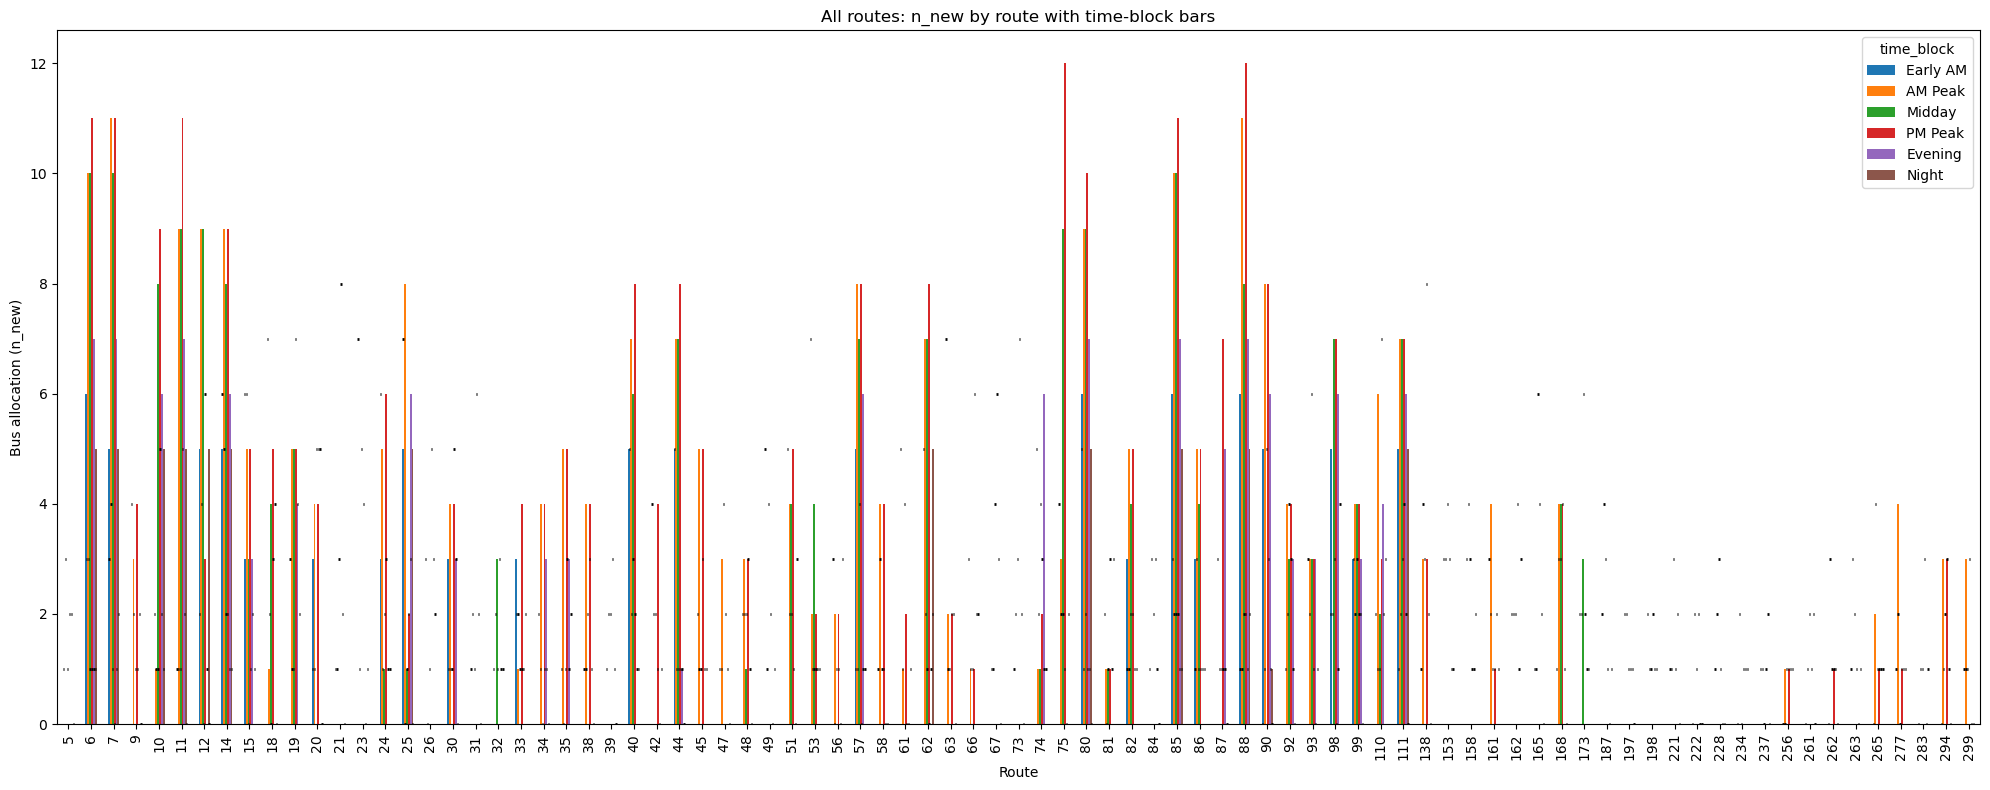

In [65]:
# Main plot: all routes.
plot_all_routes_bar(
    solution_df=solution_results,
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
    sort_routes_numeric=GRAPH_SETUP['sort_routes_numeric'],
    show_baseline_ticks=GRAPH_SETUP['show_baseline_ticks'],
    show_delta_labels=GRAPH_SETUP['show_delta_labels'],
    show_legend_baseline=GRAPH_SETUP['show_legend_baseline'],
    color_bars_by_delta=GRAPH_SETUP['color_bars_by_delta'],
)


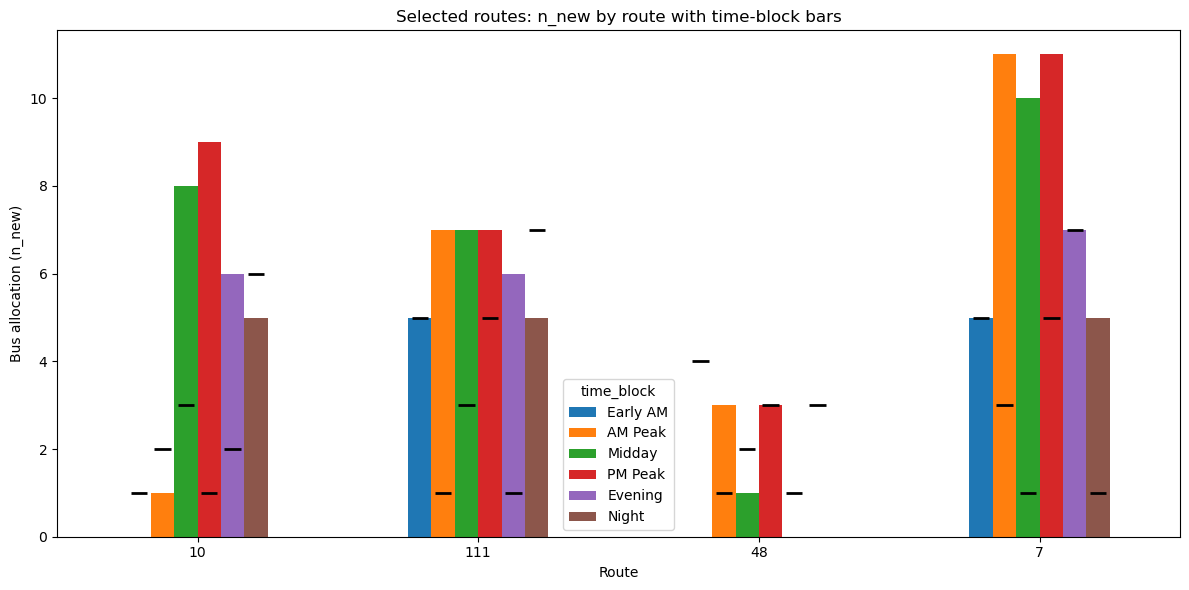

In [66]:
# Optional companion plot: only the routes of interest.
plot_selected_routes_bar(
    solution_df=solution_results,
    routes_of_interest=ROUTES_OF_INTEREST,
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
    show_baseline_ticks=GRAPH_SETUP['show_baseline_ticks'],
    show_delta_labels=GRAPH_SETUP['show_delta_labels'],
    show_legend_baseline=GRAPH_SETUP['show_legend_baseline'],
    color_bars_by_delta=GRAPH_SETUP['color_bars_by_delta'],
)
